# Lensing Cls: Ωm–S8 figure of merit across parameter space

Per-observation constraining power for the **v31** weak-lensing Cls runs in
`runs/v16/rot_in_place/cls/lensing`.

For each held-out mock observation the inference pipeline wrote a posterior chain to
`ensemble_flow_1000000/mcmc_samples.h5`. From the 2D marginal in the Ωm–S8 plane we define

$$\mathrm{FoM} = \frac{1}{\sqrt{\det \mathrm{Cov}(\Omega_m, S_8)}}, \qquad S_8 = \sigma_8\sqrt{\Omega_m/0.3}.$$

A larger FoM = a tighter 2D constraint. Because every observation has a different *true*
cosmology, plotting each observation's FoM at its true (Ωm, S8) shows **how constraining
power varies with location in parameter space** — and comparing runs at the same locations
isolates which compression extracts more information where.

**v33** (the current paper baseline) is the reference and is highlighted in every plot; the
**v34** constraining-power sweep is included automatically once its chains exist.

> This notebook only needs `numpy`, `h5py`, `matplotlib` — no TensorFlow/PyTorch — so it is
> safe to run on a login node.

In [8]:
import os, glob, re
import numpy as np
import h5py
import matplotlib.pyplot as plt

# RUNS_DIR = '/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/lensing'
RUNS_DIR = '/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/combined'
ENSEMBLE = 'ensemble_flow_1000000'   # flow subdir holding mcmc_samples.h5
MCMC_FILE = 'mcmc_samples.h5'

# Lensing training-param order (from configs.yaml): [Om, s8, w0, Aia, n_Aia, bta]
I_OM, I_S8 = 0, 1

def s8_of(sigma8, Om):
    return sigma8 * np.sqrt(Om / 0.3)

## 1. Discover runs and load chains

Runs matching `RUN_GLOBS` that have an `mcmc_samples.h5` are picked up automatically:
the `v31_*` baselines, the **v33 reference** (current paper baseline, highlighted
throughout), and the new **v34** constraining-power sweep. v34 runs appear here as soon as
their inference stage has written `mcmc_samples.h5` — until then they are simply absent.

In [ ]:
# RUN_GLOBS = ['v31_*', 'v33', 'v34_*']   # baselines + reference + new sweep
# HIGHLIGHT = 'v33'                        # reference run, highlighted in every plot
# RUN_GLOBS = ['v36_*', 'v33']   # baselines + reference + new sweep
# RUN_GLOBS = ['v37', 'v37_no_pca', 'v33']   # baselines + reference + new sweep
RUN_GLOBS = ['v37', 'v37_no_pca', 'v33']   # baselines + reference + new sweep
HIGHLIGHT = 'v33'                        # reference run, highlighted in every plot

def discover_runs(runs_dir=RUNS_DIR, patterns=RUN_GLOBS):
    found = {}
    for pat in patterns:
        for d in sorted(glob.glob(os.path.join(runs_dir, pat))):
            f = os.path.join(d, ENSEMBLE, MCMC_FILE)
            if os.path.isfile(f):
                found[os.path.basename(d)] = f
    return dict(sorted(found.items()))

runs = discover_runs()
print(f'{len(runs)} runs with {MCMC_FILE}:')
for k in runs:
    print('  ', k, '  <-- REFERENCE' if k == HIGHLIGHT else '')
assert HIGHLIGHT in runs, f'reference {HIGHLIGHT!r} has no {MCMC_FILE} yet'

3 runs with mcmc_samples.h5:
   v33   <-- REFERENCE
   v37 
   v37_no_pca 


In [10]:
def load_run(path):
    """Return dict with theta_true (n_obs,6), theta_sample (n_samp,n_obs,6), real_idx (n_obs,3)."""
    with h5py.File(path, 'r') as f:
        out = {
            'theta_true': f['theta_true'][:],
            'theta_sample': f['theta_sample'][:],
        }
        out['real_idx'] = f['real_idx'][:] if 'real_idx' in f else None
    return out

def per_obs_fom(theta_sample):
    """Vectorized Ωm–S8 FoM = 1/sqrt(det Cov) per observation. theta_sample: (n_samp, n_obs, 6)."""
    Om = theta_sample[:, :, I_OM]                 # (n_samp, n_obs)
    S8 = s8_of(theta_sample[:, :, I_S8], Om)
    Om_c = Om - Om.mean(0, keepdims=True)
    S8_c = S8 - S8.mean(0, keepdims=True)
    n = Om.shape[0]
    c_oo = (Om_c * Om_c).sum(0) / (n - 1)
    c_ss = (S8_c * S8_c).sum(0) / (n - 1)
    c_os = (Om_c * S8_c).sum(0) / (n - 1)
    det = c_oo * c_ss - c_os ** 2
    det = np.clip(det, 1e-30, None)
    return 1.0 / np.sqrt(det)                     # (n_obs,)

def truth_om_s8(theta_true):
    Om = theta_true[:, I_OM]
    return Om, s8_of(theta_true[:, I_S8], Om)

data = {}
for name, path in runs.items():
    r = load_run(path)
    om_t, s8_t = truth_om_s8(r['theta_true'])
    data[name] = {
        'fom': per_obs_fom(r['theta_sample']),
        'om_true': om_t,
        's8_true': s8_t,
        'real_idx': r['real_idx'],
    }
    has_idx = 'yes' if r['real_idx'] is not None else 'NO (excluded from §4)'
    print(f"{name:28s} n_obs={len(data[name]['fom']):4d}  median FoM={np.median(data[name]['fom']):8.1f}  real_idx={has_idx}")

v33                          n_obs=1000  median FoM=  1181.5  real_idx=yes
v37                          n_obs=1000  median FoM=  1945.9  real_idx=yes
v37_no_pca                   n_obs=1000  median FoM=  1864.1  real_idx=yes


## 2. Overall ranking (median FoM)

A single-number summary of constraining power per run (median over all observations).
This collapses the spatial information — the per-location view in §3 is the substantive one.

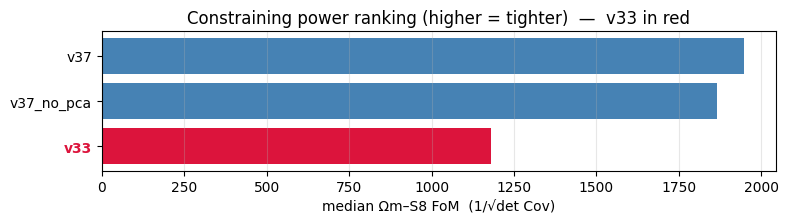

In [11]:
names = list(data)
med = np.array([np.median(data[n]['fom']) for n in names])
order = np.argsort(med)[::-1]

lab = [names[i] for i in order][::-1]
val = med[order][::-1]
col = ['crimson' if n == HIGHLIGHT else 'steelblue' for n in lab]
fig, ax = plt.subplots(figsize=(8, 0.45 * len(names) + 1))
ax.barh(lab, val, color=col)
for t in ax.get_yticklabels():
    if t.get_text() == HIGHLIGHT:
        t.set_color('crimson'); t.set_fontweight('bold')
ax.set_xlabel('median Ωm–S8 FoM  (1/√det Cov)')
ax.set_title(f'Constraining power ranking (higher = tighter)  —  {HIGHLIGHT} in red')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.show()

## 3. How FoM varies with location in parameter space

Each point is one observation, placed at its **true** (Ωm, S8) and coloured by its FoM.
A shared colour scale (robust 2–98 percentile across all runs) makes panels comparable.

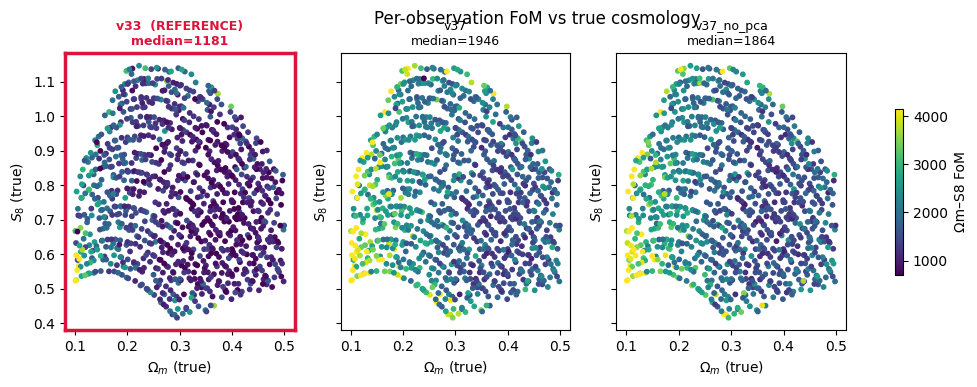

In [12]:
all_fom = np.concatenate([data[n]['fom'] for n in names])
vmin, vmax = np.percentile(all_fom, [2, 98])

ncol = 3
nrow = int(np.ceil(len(names) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.6 * nrow), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax in axes[len(names):]:
    ax.axis('off')

sc = None
for ax, n in zip(axes, names):
    d = data[n]
    sc = ax.scatter(d['om_true'], d['s8_true'], c=d['fom'], s=10,
                    cmap='viridis', vmin=vmin, vmax=vmax)
    hl = (n == HIGHLIGHT)
    ax.set_title(f"{n}{'  (REFERENCE)' if hl else ''}\nmedian={np.median(d['fom']):.0f}",
                 fontsize=9, color='crimson' if hl else 'black',
                 fontweight='bold' if hl else 'normal')
    if hl:
        for s in ax.spines.values():
            s.set_edgecolor('crimson'); s.set_linewidth(2.5)
    ax.set_xlabel(r'$\Omega_m$ (true)')
    ax.set_ylabel(r'$S_8$ (true)')
fig.colorbar(sc, ax=axes.tolist(), shrink=0.6, label='Ωm–S8 FoM')
fig.suptitle('Per-observation FoM vs true cosmology', y=1.0)
plt.show()

### 3b. 1D trends

Median FoM in bins of Ωm and of S8, overlaying all runs, to read off the dominant
dependence (lensing constraints typically tighten toward higher S8 / Ωm where the signal
is larger, and degrade near the prior edges).

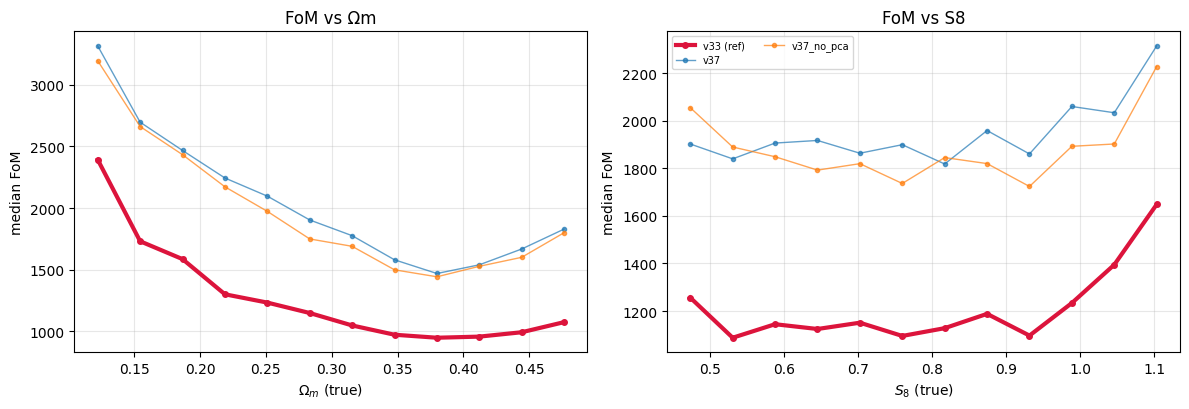

In [13]:
def binned_median(x, y, bins=12):
    edges = np.linspace(np.percentile(x, 1), np.percentile(x, 99), bins + 1)
    cen = 0.5 * (edges[:-1] + edges[1:])
    idx = np.digitize(x, edges) - 1
    med = np.array([np.median(y[idx == b]) if np.any(idx == b) else np.nan for b in range(bins)])
    return cen, med

fig, (axo, axs) = plt.subplots(1, 2, figsize=(12, 4.2))
for n in names:
    d = data[n]
    hl = (n == HIGHLIGHT)
    kw = dict(color='crimson', lw=3, marker='o', ms=4, zorder=5) if hl else dict(lw=1, marker='o', ms=3, alpha=0.7)
    c, m = binned_median(d['om_true'], d['fom'])
    axo.plot(c, m, label=(n + ' (ref)') if hl else n, **kw)
    c, m = binned_median(d['s8_true'], d['fom'])
    axs.plot(c, m, label=(n + ' (ref)') if hl else n, **kw)
axo.set_xlabel(r'$\Omega_m$ (true)'); axo.set_ylabel('median FoM')
axs.set_xlabel(r'$S_8$ (true)');     axs.set_ylabel('median FoM')
axo.set_title('FoM vs Ωm'); axs.set_title('FoM vs S8')
for a in (axo, axs):
    a.grid(alpha=0.3)
axs.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

## 4. Run-vs-run comparison at matched observations

The held-out set is identical across runs, so we can align observations by their
`real_idx = (i_sobol, i_signal, i_noise)` and compare FoM **per observation**. The map below
shows $\log_2(\mathrm{FoM}_{\rm run}/\mathrm{FoM}_{\rm ref})$ at each true cosmology: red =
this run is tighter than the reference there, blue = looser. This reveals *where* in
parameter space one compression beats another, not just on average.

Matching uses `real_idx` rather than row order (row order is **not** guaranteed identical
across runs). Any run whose `mcmc_samples.h5` predates the `real_idx` output is automatically
skipped here but still appears in §2–§3.

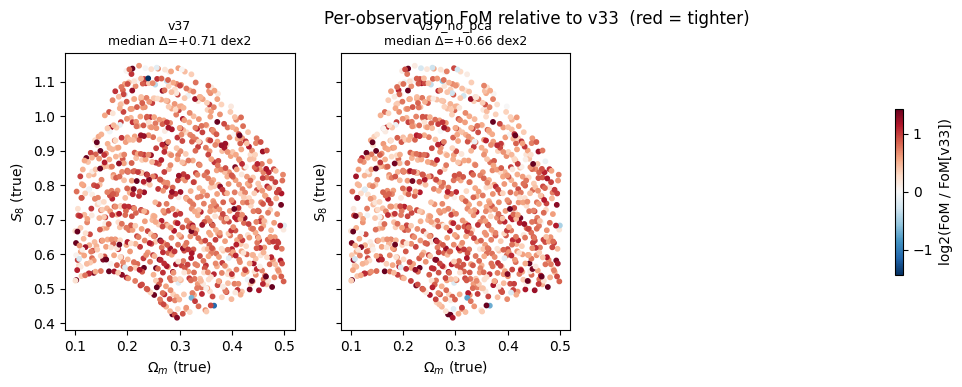

In [14]:
REFERENCE = HIGHLIGHT    # v33 = current paper baseline; every run is compared against it
assert REFERENCE in data, f'{REFERENCE} not found; pick from {list(data)}'

def idx_key(real_idx):
    return [tuple(int(v) for v in row) for row in real_idx]

ref = data[REFERENCE]
if ref['real_idx'] is None:
    raise RuntimeError('reference run has no real_idx; cannot align per observation')
ref_map = {k: i for i, k in enumerate(idx_key(ref['real_idx']))}

others = [n for n in names if n != REFERENCE and data[n]['real_idx'] is not None]
ncol = 3
nrow = int(np.ceil(len(others) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.6 * nrow), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax in axes[len(others):]:
    ax.axis('off')

sc = None
for ax, n in zip(axes, others):
    d = data[n]
    keys = idx_key(d['real_idx'])
    common = [(i, ref_map[k]) for i, k in enumerate(keys) if k in ref_map]
    if not common:
        ax.set_title(f'{n}\n(no matched obs)', fontsize=9); continue
    ii = np.array([a for a, _ in common]); jj = np.array([b for _, b in common])
    ratio = np.log2(d['fom'][ii] / ref['fom'][jj])
    lim = np.percentile(np.abs(ratio), 98)
    sc = ax.scatter(d['om_true'][ii], d['s8_true'][ii], c=ratio, s=10,
                    cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_title(f'{n}\nmedian Δ={np.median(ratio):+.2f} dex2', fontsize=9)
    ax.set_xlabel(r'$\Omega_m$ (true)'); ax.set_ylabel(r'$S_8$ (true)')
if sc is not None:
    fig.colorbar(sc, ax=axes.tolist(), shrink=0.6, label=f'log2(FoM / FoM[{REFERENCE}])')
fig.suptitle(f'Per-observation FoM relative to {REFERENCE}  (red = tighter)', y=1.0)
plt.show()

## 5. Notes

- **FoM is a 2D marginal metric** (Ωm–S8 only). The 6D parameter volume can move differently;
  swap `I_OM, I_S8` or extend `per_obs_fom` to a 6×6 determinant for a generalized FoM.
- **Constraining power ≠ calibration.** A higher FoM is only a real gain if the posteriors stay
  calibrated — cross-check the SBC/TARP/HPD plots in each run's `unblinding_plots/`. An
  overconfident run inflates FoM everywhere.
- **Spatial gradients are expected**: lensing Cls carry more signal at high S8/Ωm, and the
  Sobol grid thins out near prior edges, so FoM naturally rises toward the high-signal corner.
  The run-vs-run map (§4) divides this common trend out and isolates compression differences.
- The **v34** sweep is already in `RUN_GLOBS`; rerun the notebook once each v34 run's inference
  stage has written `mcmc_samples.h5` and it will slot into every plot alongside the v33 reference.